In [729]:
# import the packages
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
!pip install kneed
from kneed import KneeLocator

## 1. Data Preprocessing

In [731]:
# Load the dataset
df = pd.read_csv("Sales_Transactions_Dataset_Weekly.csv")

In [732]:
# Show the first 5 rows
print("Preview of the dataset:")
print(df.head())

Preview of the dataset:
  Product_Code  W0  W1  W2  W3  W4  W5  W6  W7  W8  ...  Normalized 42  \
0           P1  11  12  10   8  13  12  14  21   6  ...           0.06   
1           P2   7   6   3   2   7   1   6   3   3  ...           0.20   
2           P3   7  11   8   9  10   8   7  13  12  ...           0.27   
3           P4  12   8  13   5   9   6   9  13  13  ...           0.41   
4           P5   8   5  13  11   6   7   9  14   9  ...           0.27   

   Normalized 43  Normalized 44  Normalized 45  Normalized 46  Normalized 47  \
0           0.22           0.28           0.39           0.50           0.00   
1           0.40           0.50           0.10           0.10           0.40   
2           1.00           0.18           0.18           0.36           0.45   
3           0.47           0.06           0.12           0.24           0.35   
4           0.53           0.27           0.60           0.20           0.20   

   Normalized 48  Normalized 49  Normalized 50  No

In [733]:
# Shape of the dataset
print("\nShape of dataset (rows, columns):", df.shape)


Shape of dataset (rows, columns): (811, 107)


In [734]:
# Column names
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Product_Code', 'W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12', 'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'W19', 'W20', 'W21', 'W22', 'W23', 'W24', 'W25', 'W26', 'W27', 'W28', 'W29', 'W30', 'W31', 'W32', 'W33', 'W34', 'W35', 'W36', 'W37', 'W38', 'W39', 'W40', 'W41', 'W42', 'W43', 'W44', 'W45', 'W46', 'W47', 'W48', 'W49', 'W50', 'W51', 'MIN', 'MAX', 'Normalized 0', 'Normalized 1', 'Normalized 2', 'Normalized 3', 'Normalized 4', 'Normalized 5', 'Normalized 6', 'Normalized 7', 'Normalized 8', 'Normalized 9', 'Normalized 10', 'Normalized 11', 'Normalized 12', 'Normalized 13', 'Normalized 14', 'Normalized 15', 'Normalized 16', 'Normalized 17', 'Normalized 18', 'Normalized 19', 'Normalized 20', 'Normalized 21', 'Normalized 22', 'Normalized 23', 'Normalized 24', 'Normalized 25', 'Normalized 26', 'Normalized 27', 'Normalized 28', 'Normalized 29', 'Normalized 30', 'Normalized 31', 'Normalized 32', 'Normalized 33', 'Normalized 34', 'Normalized 35'

In [735]:
# Data types of each column
print("\nData types of columns:")
print(df.dtypes)


Data types of columns:
Product_Code      object
W0                 int64
W1                 int64
W2                 int64
W3                 int64
                  ...   
Normalized 47    float64
Normalized 48    float64
Normalized 49    float64
Normalized 50    float64
Normalized 51    float64
Length: 107, dtype: object


In [736]:
# Summary statistics for numerical columns
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               W0          W1          W2          W3          W4          W5  \
count  811.000000  811.000000  811.000000  811.000000  811.000000  811.000000   
mean     8.902589    9.129470    9.389642    9.717633    9.574599    9.466091   
std     12.067163   12.564766   13.045073   13.553294   13.095765   12.823195   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      3.000000    3.000000    3.000000    4.000000    4.000000    3.000000   
75%     12.000000   12.000000   12.000000   13.000000   13.000000   12.500000   
max     54.000000   53.000000   56.000000   59.000000   61.000000   52.000000   

               W6          W7          W8          W9  ...  Normalized 42  \
count  811.000000  811.000000  811.000000  811.000000  ...     811.000000   
mean     9.720099    9.585697    9.784217    9.681874  ...       0.299149   
std     13.347375

In [737]:
# Check for null values
print("\nNull values per column:")
print(df.isnull().sum())


Null values per column:
Product_Code     0
W0               0
W1               0
W2               0
W3               0
                ..
Normalized 47    0
Normalized 48    0
Normalized 49    0
Normalized 50    0
Normalized 51    0
Length: 107, dtype: int64


In [738]:
# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [739]:
# Check for unique values in 'Product_Code' column
if 'Product_Code' in df.columns:
    print("\nNumber of unique product codes:", df['Product_Code'].nunique())
    print("Unique product codes sample:", df['Product_Code'].unique()[:5])


Number of unique product codes: 811
Unique product codes sample: ['P1' 'P2' 'P3' 'P4' 'P5']


In [740]:
# Extract product codes and weekly features
product_codes = df['Product_Code']
weekly_cols = [col for col in df.columns if col.startswith('W')]
X = df[weekly_cols]
X

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9,...,W42,W43,W44,W45,W46,W47,W48,W49,W50,W51
0,11,12,10,8,13,12,14,21,6,14,...,4,7,8,10,12,3,7,6,5,10
1,7,6,3,2,7,1,6,3,3,3,...,2,4,5,1,1,4,5,1,6,0
2,7,11,8,9,10,8,7,13,12,6,...,6,14,5,5,7,8,14,8,8,7
3,12,8,13,5,9,6,9,13,13,11,...,9,10,3,4,6,8,14,8,7,8
4,8,5,13,11,6,7,9,14,9,9,...,7,11,7,12,6,6,5,11,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,0,0,1,0,0,2,1,0,0,1,...,0,1,1,0,0,1,0,0,2,0
807,0,1,0,0,1,2,2,6,0,1,...,3,3,4,2,4,5,5,5,6,5
808,1,0,0,0,1,1,2,1,1,0,...,2,0,0,2,2,0,0,0,4,3
809,0,0,0,1,0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,2,0


In [741]:
# Remove near-zero variance features
selector = VarianceThreshold(threshold = 0.01)
X_reduced = selector.fit_transform(X)
retained_cols = [weekly_cols[i] for i in selector.get_support(indices = True)]
removed_count = len(weekly_cols) - len(retained_cols)
print(f"\nRemoved {removed_count} low-variance feature(s), retained {len(retained_cols)}.")


Removed 0 low-variance feature(s), retained 52.


In [742]:
# Normalize only retained weekly columns using RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_reduced)

# Create final scaled DataFrame with retained columns
df_scaled = pd.DataFrame(X_scaled, columns = retained_cols)
df_scaled.insert(0, 'Product_Code', product_codes)

print("\nNormalized Weekly Sales (first 5 rows and first 5 columns):")
print(df_scaled[retained_cols].iloc[:5, :5])


Normalized Weekly Sales (first 5 rows and first 5 columns):
         W0        W1        W2        W3        W4
0  0.666667  0.750000  0.583333  0.307692  0.692308
1  0.333333  0.250000  0.000000 -0.153846  0.230769
2  0.333333  0.666667  0.416667  0.384615  0.461538
3  0.750000  0.416667  0.833333  0.076923  0.384615
4  0.416667  0.166667  0.833333  0.538462  0.153846



Number of PCA components to retain 95% variance: 11
Shape of data after PCA: (811, 11)


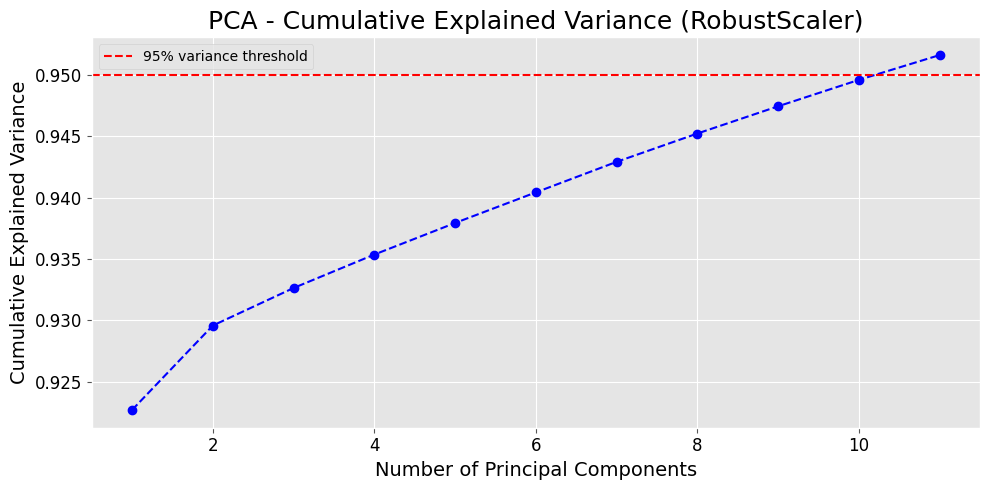

In [743]:
# Apply PCA: retain 95% of variance
pca = PCA(n_components = 0.95)
X_pca_reduced = pca.fit_transform(df_scaled.drop(columns = ['Product_Code']))

print(f"\nNumber of PCA components to retain 95% variance: {pca.n_components_}")
print("Shape of data after PCA:", X_pca_reduced.shape)

# Cumulative variance plot
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize = (10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker = 'o', linestyle = '--', color = 'b')
plt.axhline(y = 0.95, color = 'r', linestyle = '--', label = '95% variance threshold') 
plt.xlabel('Number of Principal Components', fontsize = 14, color = 'black')
plt.ylabel('Cumulative Explained Variance', fontsize = 14, color = 'black')
plt.xticks(fontsize = 12, color = 'black')
plt.yticks(fontsize = 12, color = 'black')
plt.title('PCA - Cumulative Explained Variance (RobustScaler)', fontsize = 18, color = 'black')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig("PCARobustScalar.png", format = 'png', dpi = 400)  

# Display the plot
plt.show()

## 2. Data Analysis

In [745]:
# Total sales per week (sum across products)
total_sales_per_week = df[weekly_cols].sum()
total_sales_per_week

W0     7220
W1     7404
W2     7615
W3     7881
W4     7765
W5     7677
W6     7883
W7     7774
W8     7935
W9     7852
W10    7940
W11    7849
W12    7970
W13    7856
W14    8035
W15    8147
W16    8137
W17    8033
W18    8116
W19    7822
W20    7988
W21    7875
W22    8031
W23    7998
W24    8245
W25    7212
W26    5637
W27    5834
W28    5988
W29    5952
W30    6170
W31    6172
W32    6293
W33    6412
W34    6482
W35    6486
W36    6500
W37    6548
W38    6692
W39    6460
W40    6636
W41    6683
W42    6808
W43    6746
W44    6840
W45    6939
W46    7072
W47    7032
W48    7035
W49    7214
W50    7187
W51    7209
dtype: int64

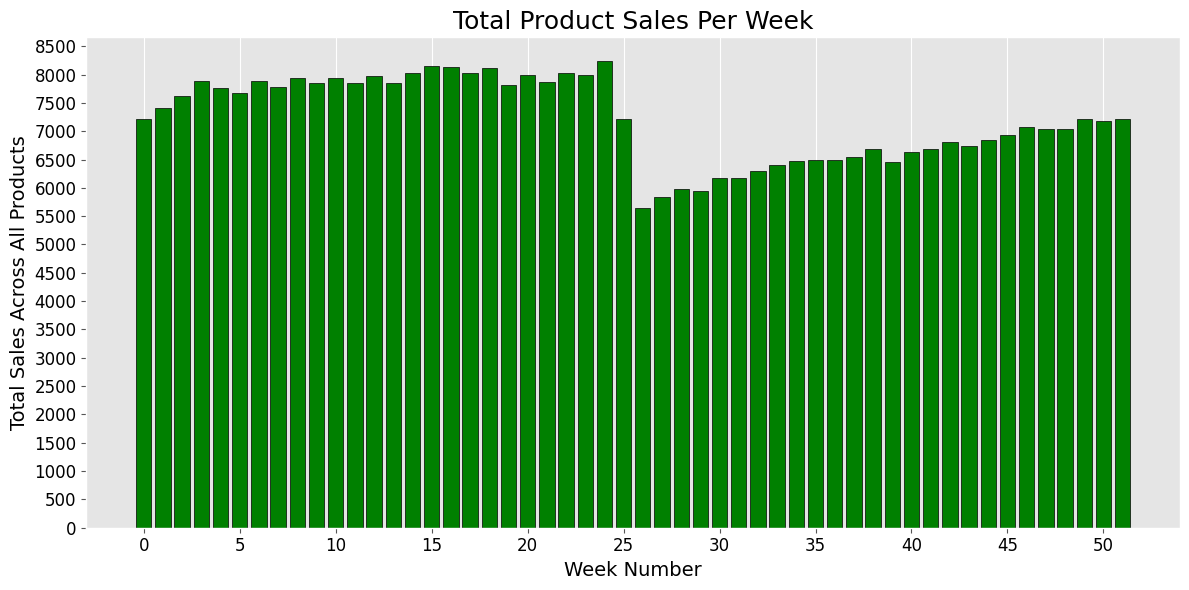

In [746]:
# Histogram 1
plt.figure(figsize = (12, 6))
plt.bar(range(52), total_sales_per_week, color = 'green', edgecolor = 'black')
plt.title("Total Product Sales Per Week", fontsize = 18, color = 'black')
plt.xlabel("Week Number", fontsize = 14, color = 'black')
plt.ylabel("Total Sales Across All Products", fontsize = 14, color = 'black')
plt.grid(axis = 'y')
plt.xticks(range(0, 52, 5), fontsize = 12, color = 'black')
plt.yticks(range(0, int(total_sales_per_week.max()) + 500, 500), fontsize = 12, color = 'black')
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig("Hist1.png", format = 'png', dpi = 400)  

# Display the plot
plt.show()

In [747]:
# Total sales per product (sum across 52 weeks)
total_sales_per_product = df[weekly_cols].sum(axis = 1)
total_sales_per_product

0      501
1      207
2      452
3      430
4      440
      ... 
806     23
807    142
808     26
809     17
810     16
Length: 811, dtype: int64

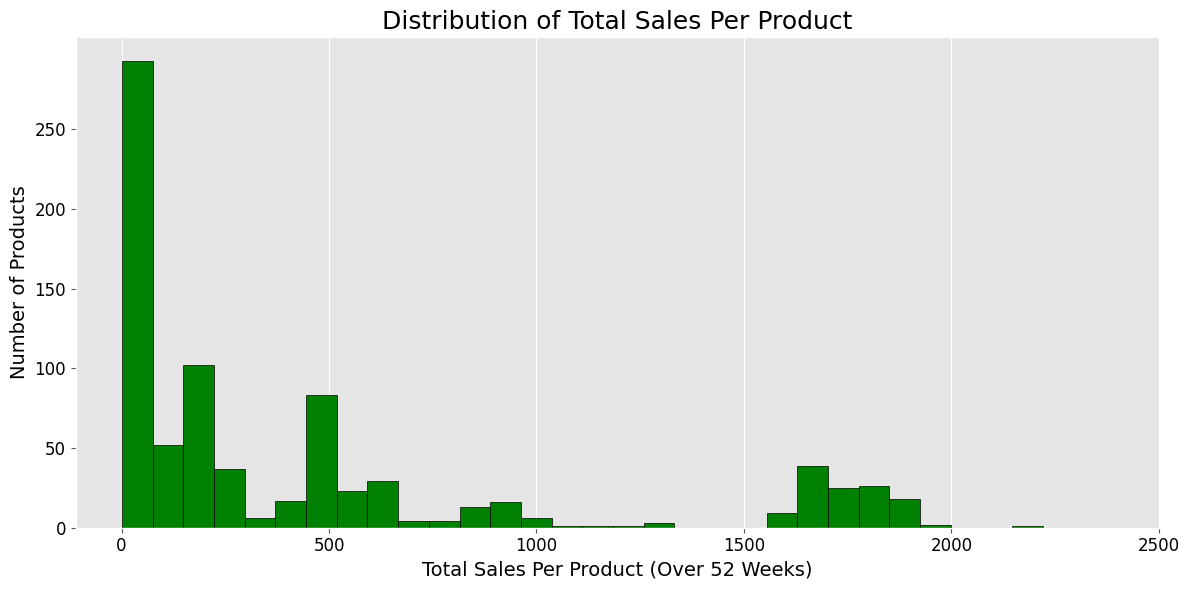

In [748]:
# Histogram 2
plt.figure(figsize = (12, 6))
plt.hist(total_sales_per_product, bins = 30, color = 'green', edgecolor = 'black')
plt.title("Distribution of Total Sales Per Product", fontsize = 18, color = 'black')
plt.xlabel("Total Sales Per Product (Over 52 Weeks)", fontsize = 14, color = 'black')
plt.ylabel("Number of Products", fontsize = 14, color = 'black')
plt.grid(axis = 'y')
plt.xticks(range(0, int(total_sales_per_product.max()) + 500, 500), fontsize = 12, color = 'black')
plt.yticks(range(0, 300, 50), fontsize = 12, color = 'black')
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig("Hist2.png", format = 'png', dpi = 400)  

# Display the plot
plt.show()

## 3. DBSCAN 

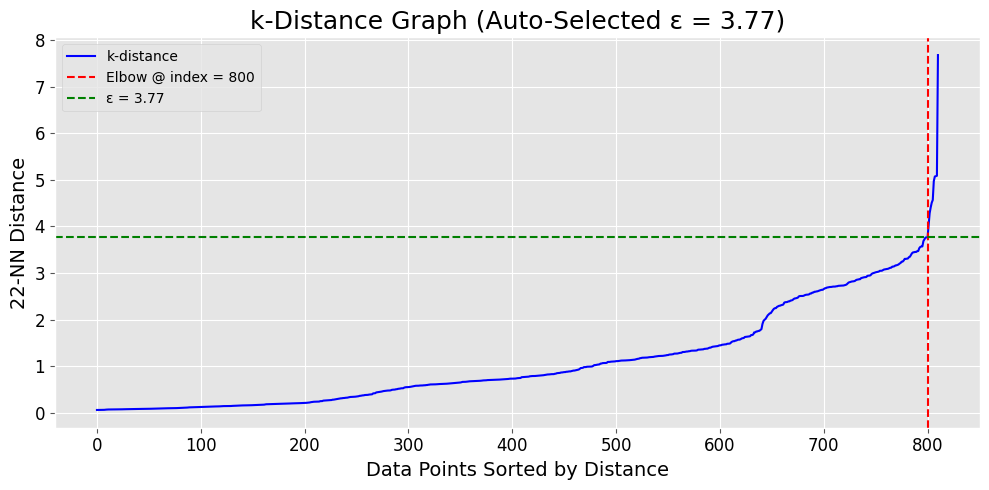

<Figure size 100x100 with 0 Axes>

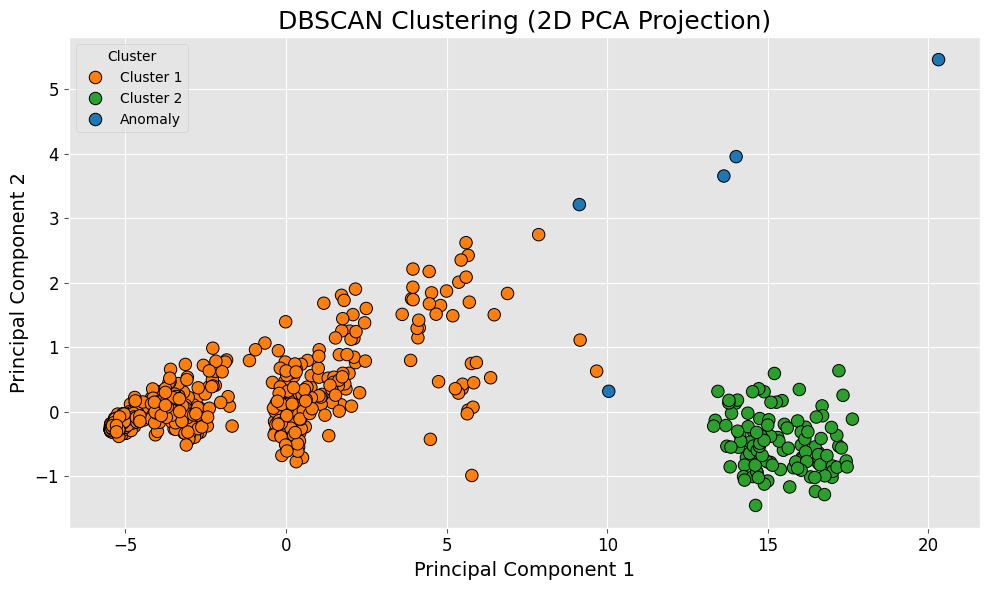


Cluster Distribution:
Cluster_Name
Anomaly        5
Cluster 1    689
Cluster 2    117
Name: count, dtype: int64

Top 5 Most Anomalous Products:
Product_Code       W0       W1       W2       W3       W4
        P208 2.250000 1.916667 2.750000 2.230769 2.230769
        P262 1.833333 2.333333 2.500000 1.461538 2.615385
        P409 3.250000 3.750000 2.916667 3.000000 2.384615
        P557 2.083333 1.666667 2.666667 2.307692 2.230769
        P615 1.166667 1.083333 1.333333 1.230769 1.153846


In [807]:
# Determine optimal epsilon using k-distance graph
min_samples = 2 * X_pca_reduced.shape[1]  
neighbors = NearestNeighbors(n_neighbors = min_samples)
neighbors_fit = neighbors.fit(X_pca_reduced)
distances, indices = neighbors_fit.kneighbors(X_pca_reduced)

# Sort distances to get the k-distance graph
k_distances = np.sort(distances[:, -1])

# Automatically detect the elbow using KneeLocator
kneedle = KneeLocator(range(len(k_distances)), k_distances, curve = "convex", direction = "increasing")
eps_value = k_distances[kneedle.knee] if kneedle.knee is not None else 2.0  

# Plot the k-distance graph with epsilon
plt.figure(figsize = (10, 5))
plt.plot(k_distances, color = 'blue', label = 'k-distance')
plt.axvline(kneedle.knee, color = 'red', linestyle = '--', label = f'Elbow @ index = {kneedle.knee}')
plt.axhline(eps_value, color = 'green', linestyle = '--', label = f'ε = {eps_value:.2f}')
plt.xlabel('Data Points Sorted by Distance', fontsize = 14, color = 'black')
plt.ylabel(f'{min_samples}-NN Distance', fontsize = 14, color = 'black')
plt.xticks(fontsize = 12, color = 'black')
plt.yticks(fontsize = 12, color = 'black')
plt.title(f'k-Distance Graph (Auto-Selected ε = {eps_value:.2f})', fontsize = 18, color = 'black')
plt.legend(loc = 'best')
plt.grid(True)
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig("KDistanceGraph.png", format = 'png', dpi = 400)  
# Display the plot
plt.show()


# Run DBSCAN with selected epsilon
dbscan = DBSCAN(eps = eps_value, min_samples = min_samples)
dbscan_labels = dbscan.fit_predict(X_pca_reduced)

# Assign cluster names
df_dbscan = df_scaled.copy()
df_dbscan['Cluster_Label'] = dbscan_labels
valid_clusters = sorted(set(dbscan_labels) - {-1})  
cluster_mapping = {old: f'Cluster {i+1}' for i, old in enumerate(valid_clusters)}
df_dbscan['Cluster_Name'] = df_dbscan['Cluster_Label'].map(cluster_mapping)
df_dbscan['Cluster_Name'] = df_dbscan['Cluster_Name'].fillna('Anomaly')

# Add spacing between 2 plots
plt.figure(figsize = (1, 1))

# PCA scatter plot with clusters
pca_df = pd.DataFrame(X_pca_reduced[:, :2], columns = ['PC1', 'PC2'])
pca_df['Cluster'] = df_dbscan['Cluster_Name']

# Set desired cluster-color mapping
tab10_colors = sns.color_palette('tab10')
custom_palette = {
    'Anomaly': tab10_colors[0],    
    'Cluster 1': tab10_colors[1],  
    'Cluster 2': tab10_colors[2],  
}

# Set hue order to match palette keys
hue_order = ['Cluster 1', 'Cluster 2', 'Anomaly']

# Plot
plt.figure(figsize = (10, 6))
sns.scatterplot(
    data = pca_df,
    x = 'PC1', y = 'PC2',
    hue = 'Cluster',
    palette = custom_palette,
    hue_order = hue_order,
    s = 80,
    edgecolor = 'black'
)

plt.title("DBSCAN Clustering (2D PCA Projection)", fontsize = 18, color = 'black')
plt.xlabel("Principal Component 1", fontsize = 14, color = 'black')
plt.ylabel("Principal Component 2", fontsize = 14, color = 'black')
plt.xticks(fontsize = 12, color = 'black')
plt.yticks(fontsize = 12, color = 'black')
plt.legend(loc = 'upper left', title = 'Cluster')
plt.grid(True)
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig("DBScanClustering.png", format = 'png', dpi = 400)  
# Display the plot
plt.show()

# Step 7: Cluster statistics
cluster_counts = df_dbscan['Cluster_Name'].value_counts().sort_index()
print("\nCluster Distribution:")
print(cluster_counts)

# Step 8: Print top 5 most anomalous products
anomalies = df_dbscan[df_dbscan['Cluster_Name'] == 'Anomaly']
top_anomalies = anomalies[['Product_Code'] + retained_cols[:5]].head(5)

print("\nTop 5 Most Anomalous Products:")
print(top_anomalies.to_string(index = False))

## 4. KMeans Clustering 

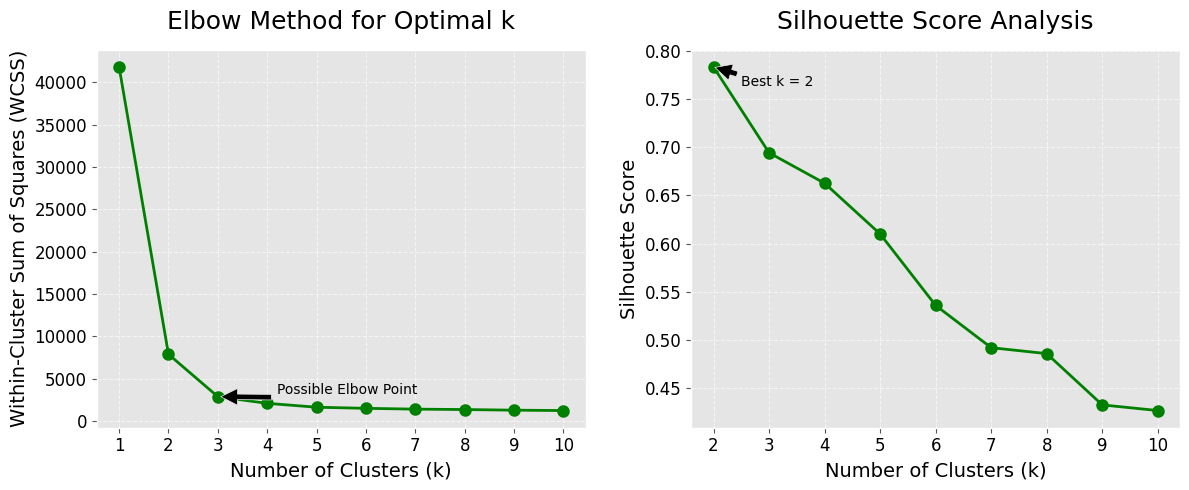

 Optimal k selected based on silhouette score: 2
Silhouette Score (k = 2): 0.783


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [811]:
# Style and layout
plt.figure(figsize = (12, 5))
plt.style.use('ggplot')
consistent_color = 'green'

# Elbow Method
plt.subplot(1, 2, 1)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, init='k-means++', random_state = 42, n_init = 10)
    kmeans.fit(X_pca_reduced)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, color = consistent_color, 
         marker = 'o', linestyle = '-', linewidth = 2, markersize = 8)
plt.title('Elbow Method for Optimal k', fontsize = 18, color = 'black', pad = 15)
plt.xlabel('Number of Clusters (k)', fontsize = 14, color = 'black')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize = 14, color = 'black')
plt.xticks(range(1, 11), fontsize = 12, color = 'black')
plt.yticks(fontsize = 12, color = 'black')
plt.grid(True, linestyle='--', alpha = 0.6)

# Annotate elbow 
elbow_k = 3
plt.annotate('Possible Elbow Point', 
             xy = (elbow_k, wcss[elbow_k-1]), 
             xytext = (elbow_k + 1.2, wcss[elbow_k-1] * 1.1),
             arrowprops = dict(facecolor = 'black', shrink = 0.05),
             fontsize = 10)

# Save the plot as a PNG image
plt.savefig("ElbowMethod.png", format = 'png', dpi = 400)  


# Silhouette Score Analysis
plt.subplot(1, 2, 2)
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(X_pca_reduced)
    silhouette_scores.append(silhouette_score(X_pca_reduced, labels))

plt.plot(range(2, 11), silhouette_scores, color = consistent_color,
         marker = 'o', linestyle = '-', linewidth = 2, markersize = 8)
plt.title('Silhouette Score Analysis', fontsize = 18, color = 'black', pad = 15)
plt.xlabel('Number of Clusters (k)', fontsize = 14, color = 'black')
plt.ylabel('Silhouette Score', fontsize = 14, color = 'black')
plt.xticks(range(2, 11), fontsize = 12, color = 'black')
plt.yticks(fontsize = 12, color = 'black')
plt.grid(True, linestyle = '--', alpha = 0.6)

# Annotate best k based on silhouette
best_k = np.argmax(silhouette_scores) + 2
best_score = silhouette_scores[best_k - 2]
plt.annotate(f'Best k = {best_k}', 
             xy = (best_k, best_score),
             xytext = (best_k + 0.5, best_score - 0.02),
             arrowprops = dict(facecolor = 'black', shrink = 0.05),
             fontsize = 10)

plt.tight_layout(w_pad = 2.5) 
# Save the plot as a PNG image
plt.savefig("SilhouetteScore.png", format = 'png', dpi = 400)  

# Display the plot
plt.show()

# Final selection
print(f" Optimal k selected based on silhouette score: {best_k}")

# Exact Silhouette Score
kmeans = KMeans(n_clusters = 2, random_state = 42).fit(X_pca_reduced)
print(f"Silhouette Score (k = 2): {silhouette_score(X_pca_reduced, kmeans.labels_):.3f}")

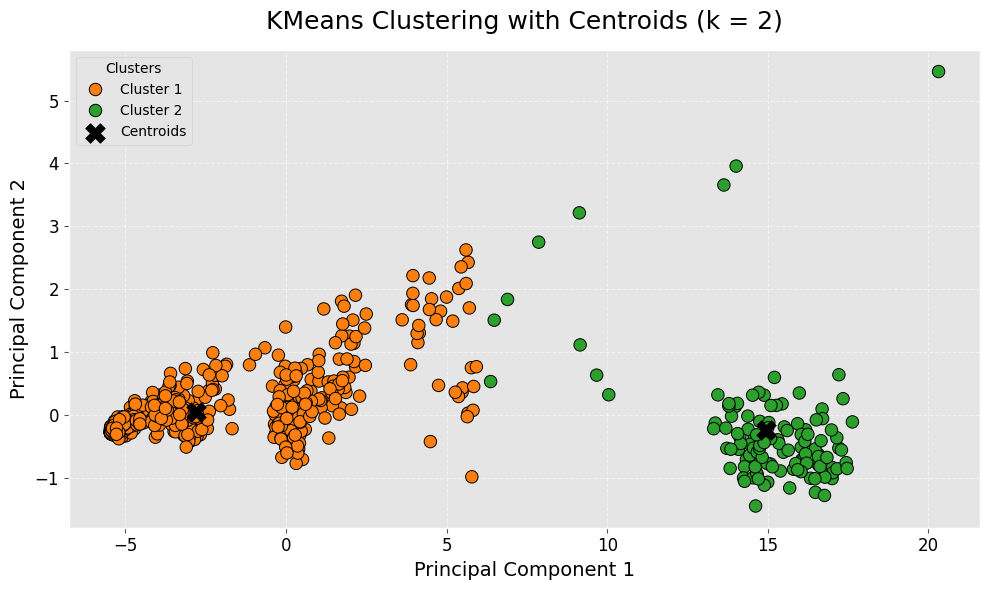

In [753]:
# Final KMeans with best_k
kmeans_final = KMeans(n_clusters = best_k, init = 'k-means++', random_state = 42, n_init = 10)
kmeans_labels_final = kmeans_final.fit_predict(X_pca_reduced)
centroids = kmeans_final.cluster_centers_

# DataFrame for plotting
kmeans_centroid_df = pd.DataFrame(X_pca_reduced[:, :2], columns = ['PC1', 'PC2'])
kmeans_centroid_df['Cluster'] = [f'Cluster {label + 1}' for label in kmeans_labels_final]

# Set hue order explicitly and assign correct colors from tab10
hue_order = [f'Cluster {i+1}' for i in range(best_k)]

# Define color palette for tab10 with Cluster 1 = orange (index 1), Cluster 2 = green (index 2)
tab10_colors = sns.color_palette('tab10')
custom_palette = {
    'Cluster 1': tab10_colors[1],  
    'Cluster 2': tab10_colors[2],  
}

# Plot
plt.figure(figsize = (10, 6))
sns.scatterplot(
    data = kmeans_centroid_df,
    x = 'PC1', y = 'PC2',
    hue = 'Cluster',
    hue_order = hue_order,
    palette = custom_palette,
    s = 80,
    edgecolor = 'black'
)

# Plot centroids
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    s = 200,
    c = 'black',
    marker = 'X',
    label = 'Centroids'
)

plt.title(f"KMeans Clustering with Centroids (k = {best_k})", fontsize = 18, color = 'black', pad = 15)
plt.xlabel("Principal Component 1", fontsize = 14, color = 'black')
plt.ylabel("Principal Component 2", fontsize = 14, color = 'black')
plt.xticks(fontsize = 12, color = 'black')
plt.yticks(fontsize = 12, color= 'black')
plt.legend(title = 'Clusters', loc = 'upper left')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.tight_layout()
# Save the plot as a PNG image
plt.savefig("KMeansClustering.png", format = 'png', dpi = 400)  

# Display the plot
plt.show()

## 5. Cluster Visualization

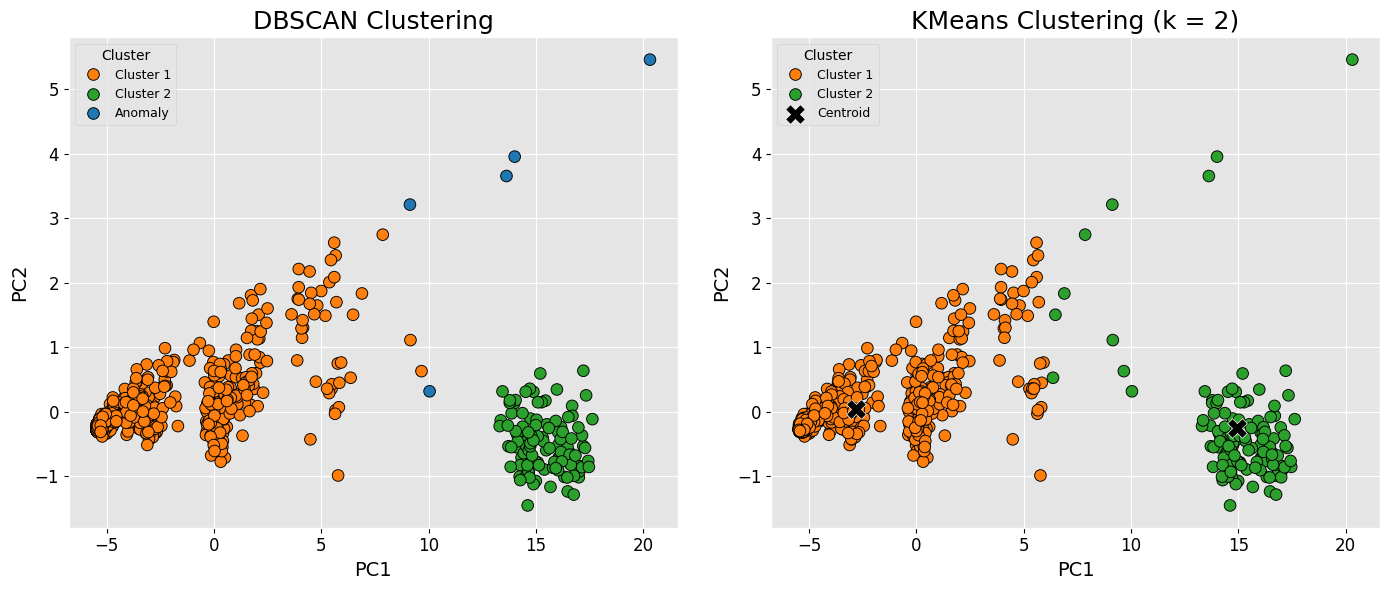

In [789]:
# Standardize KMeans cluster names
kmeans = KMeans(n_clusters = best_k, init = 'k-means++', random_state = 42, n_init = 10)
kmeans_labels = kmeans.fit_predict(X_pca_reduced)
kmeans_named_labels = [f'Cluster {label + 1}' for label in kmeans_labels]
df_kmeans_plot = pd.DataFrame(X_pca_reduced[:, :2], columns = ['PC1', 'PC2'])
df_kmeans_plot['Cluster_Name'] = kmeans_named_labels

# DBSCAN already has named clusters (Cluster X or Anomaly)
df_dbscan_plot = pd.DataFrame(X_pca_reduced[:, :2], columns = ['PC1', 'PC2'])
df_dbscan_plot['Cluster_Name'] = df_dbscan['Cluster_Name']

# Combine all unique cluster names and sort (Anomaly last)
all_clusters = sorted(set(df_kmeans_plot['Cluster_Name']) | set(df_dbscan_plot['Cluster_Name']),
                      key = lambda x: (x != 'Anomaly', int(x.split()[-1]) if x != 'Anomaly' else float('inf')))

# Create consistent color palette
palette = dict(zip(all_clusters, sns.color_palette('tab10', len(all_clusters))))

# Set consistent hue order for legend
hue_order = [c for c in all_clusters if c != 'Anomaly']
hue_order_kmeans = hue_order.copy()  
hue_order_dbscan = hue_order + ['Anomaly'] 

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DBSCAN Plot
sns.scatterplot(data = df_dbscan_plot, x = 'PC1', y = 'PC2',
                hue = 'Cluster_Name', palette = palette, ax = axes[0], s = 70, edgecolor = 'black', hue_order = hue_order_dbscan)
axes[0].set_title("DBSCAN Clustering", fontsize = 18, color = 'black')
axes[0].set_xlabel("PC1", fontsize = 14, color = 'black')
axes[0].set_ylabel("PC2", fontsize = 14, color = 'black')
axes[0].tick_params(axis = 'x', labelsize = 12, colors = 'black')
axes[0].tick_params(axis = 'y', labelsize = 12, colors = 'black')
axes[0].legend(title = 'Cluster', loc = 'upper left', fontsize = 9, title_fontsize = 10)
# Save the plot as a PNG image
plt.savefig("DBSCANClustering.png", format = 'png', dpi = 400)  


# KMeans Plot
df_kmeans_plot['Cluster_Name'] = pd.Categorical(df_kmeans_plot['Cluster_Name'], categories = hue_order_kmeans, ordered = True)
sns.scatterplot(data=df_kmeans_plot.sort_values('Cluster_Name'), x = 'PC1', y = 'PC2',
                hue = 'Cluster_Name', palette = palette, ax = axes[1], s = 70, edgecolor =  'black', hue_order = hue_order_kmeans)

# Add centroids
centroids_2d = kmeans.cluster_centers_[:, :2]  
axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                marker = 'X', s = 200, c = 'black', label = 'Centroid', edgecolor = 'white')

axes[1].set_title(f"KMeans Clustering (k = {best_k})", fontsize = 18, color = 'black')
axes[1].set_xlabel("PC1", fontsize = 14, color ='black')
axes[1].set_ylabel("PC2", fontsize = 14, color ='black')
axes[1].tick_params(axis = 'x', labelsize =12, colors ='black')
axes[1].tick_params(axis = 'y', labelsize =12, colors ='black')
axes[1].legend(title = 'Cluster', loc = 'upper left', fontsize = 9, title_fontsize = 10)
plt.tight_layout(w_pad = 2.5)
# Save the plot as a PNG image
plt.savefig("KMeansK2.png", format = 'png', dpi = 400)  
# Display the plot
plt.show()

## 6. Anomaly Comparison

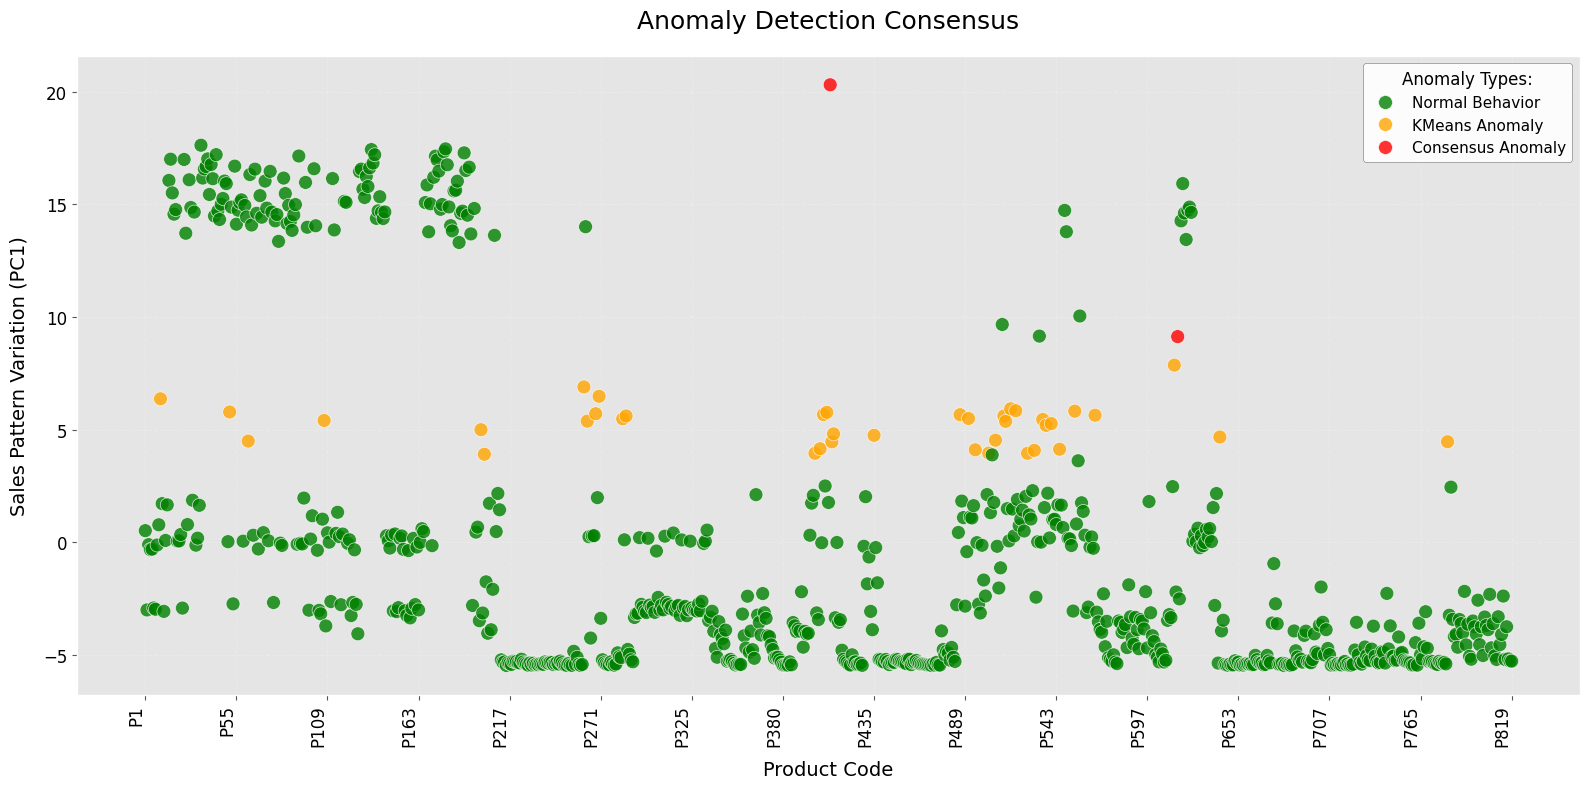

In [757]:
# KMeans anomaly: points farthest from their cluster centroids
distances = kmeans.transform(X_pca_reduced)
min_distances = np.min(distances, axis = 1)
kmeans_threshold = np.percentile(min_distances, 95)  
kmeans_anomalies = min_distances > kmeans_threshold

# DBSCAN anomaly: labeled as -1 (noise)
dbscan_anomalies = df_dbscan['Cluster_Name'] == 'Anomaly'

# Consensus: both DBSCAN and KMeans marked it as anomaly
consensus_anomalies = kmeans_anomalies & dbscan_anomalies

# Classify Each Point 
anomaly_type = np.where(consensus_anomalies, 'Consensus Anomaly',
                 np.where(kmeans_anomalies, 'KMeans Anomaly', 'Normal Behavior'))

# Create DataFrame for Plotting
anomaly_df = pd.DataFrame({
    'Product_Code': product_codes,
    'PC1': X_pca_reduced[:, 0], 
    'Anomaly_Type': anomaly_type
})

# Define Plotting Parameters
anomaly_palette = {
    'Normal Behavior': 'green',
    'KMeans Anomaly': 'orange',
    'Consensus Anomaly': 'red'
}

# Plot the Scatter Plot 
plt.figure(figsize = (16, 8))
ax = sns.scatterplot(
    data = anomaly_df,
    x = 'Product_Code',
    y = 'PC1',
    hue = 'Anomaly_Type',
    palette = anomaly_palette,
    s = 100,
    alpha = 0.8,
    edgecolor = 'white',
    linewidth = 0.5
) 

# Formatting
plt.title('Anomaly Detection Consensus', pad = 20, fontsize = 18, color = 'black')
plt.xlabel('Product Code', fontsize = 14, color = 'black', labelpad = 10)
plt.ylabel('Sales Pattern Variation (PC1)', fontsize = 14, color= 'black', labelpad = 10)
plt.yticks(fontsize = 12, color = 'black')

# Show max 15 x-ticks for readability
n = len(product_codes)
step = max(1, n // 15)
plt.xticks(range(0, n, step), product_codes.iloc[range(0, n, step)], rotation = 90, ha = 'right', fontsize = 12, color = 'black')

# Legend styling
legend = ax.legend(
    title = 'Anomaly Types:',
    title_fontsize = 12,
    fontsize = 11,
    loc = 'upper right',
    frameon = True,
    framealpha = 0.9,
    facecolor = 'white',
    edgecolor = 'gray'
)

# Grid & layout
plt.grid(True, linestyle = '--', alpha = 0.2)
plt.tight_layout()

# Save the plot as a PNG image
plt.savefig("Consensus.png", format = 'png', dpi = 400)  

# Display the plot
plt.show()

## 7. Metric Evaluation


ANOMALY DETECTION EVALUATION METRICS

--- Runtime Performance ---
Dbscan Training Time: 0.0099 seconds
Dbscan Inference Time: 0.0000 seconds
Kmeans Training Time: 0.0353 seconds
Kmeans Inference Time: 0.0019 seconds
Consensus Training Time: 0.0000 seconds
Consensus Inference Time: 0.0006 seconds

--- K-means Metrics ---
Accuracy: 0.9507
Precision: 0.0244
Recall: 1.0000
F1 Score: 0.0476
Specificity: 0.9506
Roc Auc: 0.9716
Log Loss: 0.4715

--- DBSCAN Metrics ---
Accuracy: 0.9951
Precision: 0.2000
Recall: 1.0000
F1 Score: 0.3333
Specificity: 0.9951
Roc Auc: 0.9975
Silhouette Score: 0.7859

--- Consensus Model Metrics ---
Accuracy: 0.9988
Precision: 0.5000
Recall: 1.0000
F1 Score: 0.6667
Roc Auc: 1.0000
Specificity: 0.9988


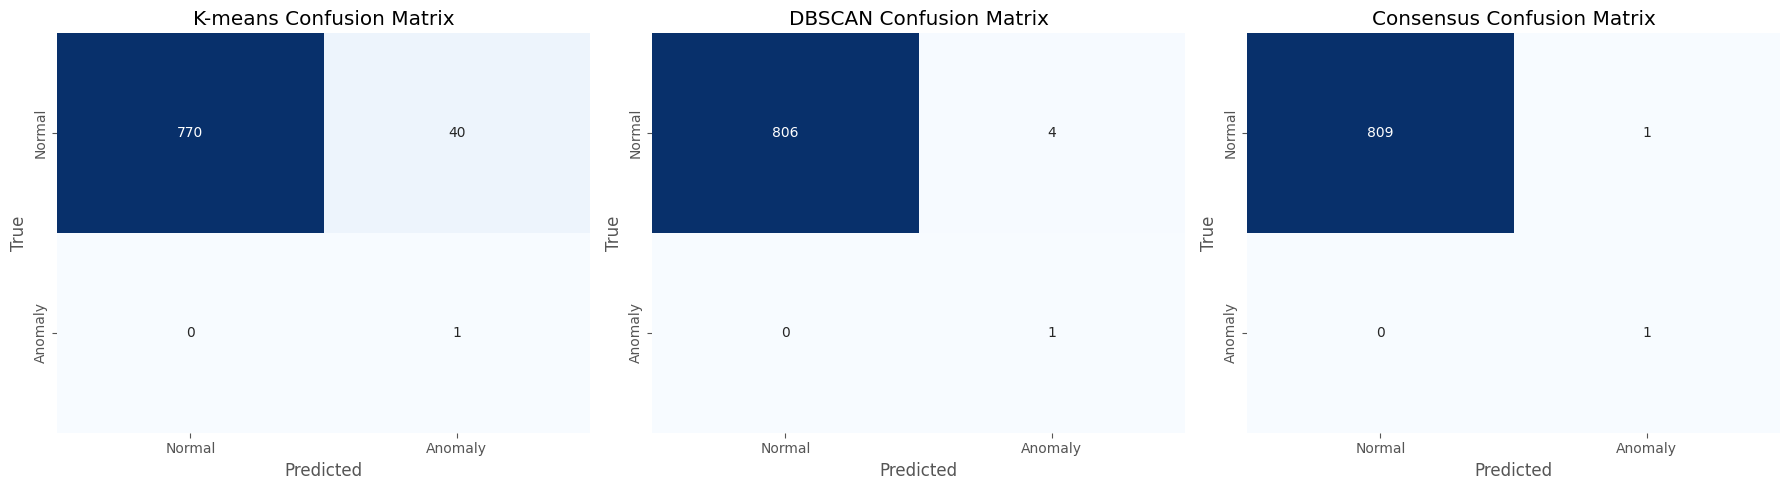

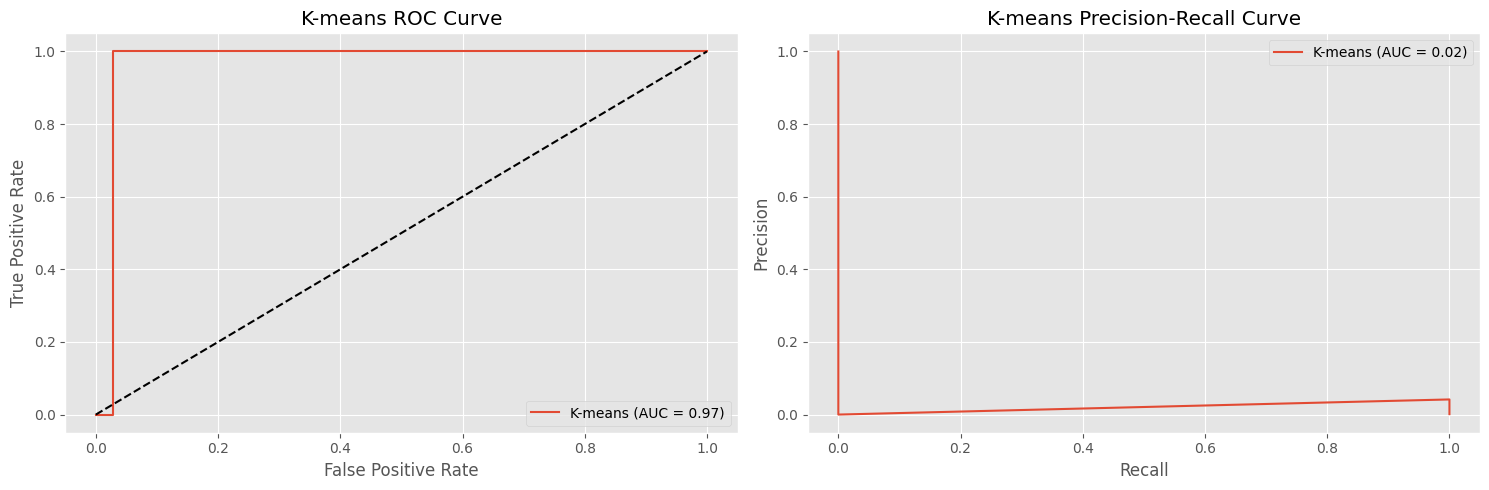

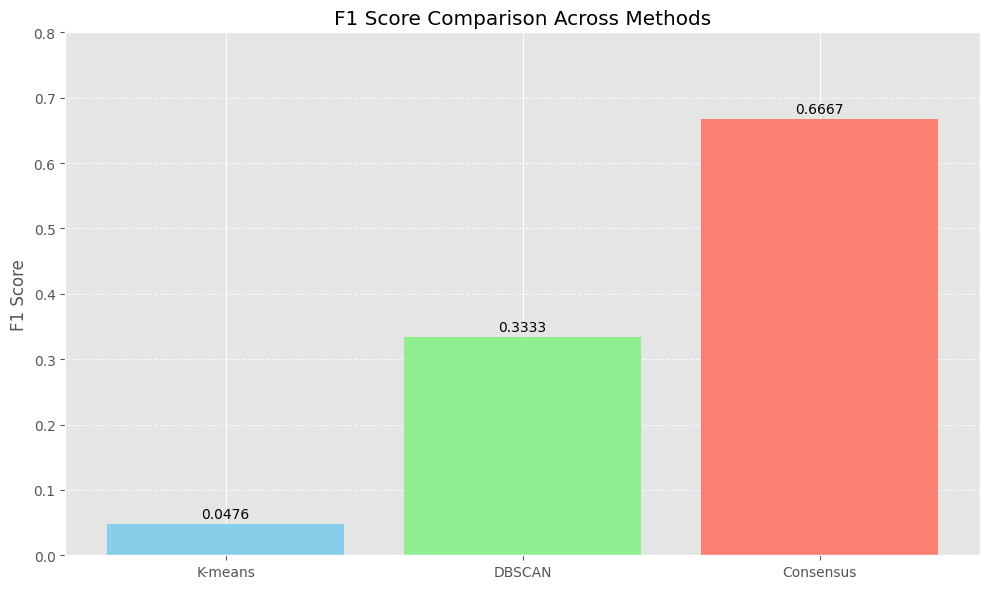


NOTE: The evaluation is based on synthetic 'ground truth' generated using statistical outlier detection.
For real-world deployment, replace this with actual labeled anomaly data or expert feedback.


In [803]:
# Evaluation Metrics for Anomaly Detection
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, log_loss, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, silhouette_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store all metrics
metrics = {}

# Step 7.2: Synthetic Ground Truth
def create_synthetic_ground_truth(df, weekly_cols, threshold = 3.0):
    total_sales = df[weekly_cols].sum(axis = 1)
    mean_sales = total_sales.mean()
    std_sales = total_sales.std()
    z_scores_sales = (total_sales - mean_sales) / std_sales

    volatility = df[weekly_cols].std(axis = 1)
    mean_volatility = volatility.mean()
    std_volatility = volatility.std()
    z_scores_volatility = (volatility - mean_volatility) / std_volatility

    is_outlier_sales = abs(z_scores_sales) > threshold
    is_outlier_volatility = abs(z_scores_volatility) > threshold
    return (is_outlier_sales | is_outlier_volatility).astype(int)

# Generate synthetic ground truth labels
synthetic_labels = create_synthetic_ground_truth(df, weekly_cols)

# Binary predictions
kmeans_binary = kmeans_anomalies.astype(int)
dbscan_binary = dbscan_anomalies.astype(int)
consensus_binary = consensus_anomalies.astype(int)

# Runtime Performance Metrics
def measure_execution_time(func, *args, **kwargs):
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    return result, end_time - start_time

# DBSCAN training time
_, dbscan_train_time = measure_execution_time(DBSCAN(eps = eps_value, min_samples = min_samples).fit, X_pca_reduced)

# DBSCAN inference time
_, dbscan_inference_time = measure_execution_time(lambda: (dbscan_labels == -1).astype(int))

# KMeans training time
_, kmeans_train_time = measure_execution_time(KMeans(n_clusters = best_k, init = 'k-means++', 
                                                     random_state = 42, n_init = 10).fit, X_pca_reduced)

# KMeans inference time
_, kmeans_inference_time = measure_execution_time(kmeans.predict, X_pca_reduced)

# Consensus inference time (majority vote)
_, consensus_inference_time = measure_execution_time(lambda: (kmeans_binary + dbscan_binary >= 1).astype(int))

# Consensus training time is negligible
consensus_train_time = 0.0

# Store runtime metrics
metrics['runtime'] = {
    'dbscan_training_time': dbscan_train_time,
    'dbscan_inference_time': dbscan_inference_time,
    'kmeans_training_time': kmeans_train_time,
    'kmeans_inference_time': kmeans_inference_time,
    'consensus_training_time': consensus_train_time,
    'consensus_inference_time': consensus_inference_time,
}

# Classification Metrics
# KMeans Metrics
metrics['kmeans'] = {
    'accuracy': accuracy_score(synthetic_labels, kmeans_binary),
    'precision': precision_score(synthetic_labels, kmeans_binary),
    'recall': recall_score(synthetic_labels, kmeans_binary),
    'f1_score': f1_score(synthetic_labels, kmeans_binary),
    'specificity': confusion_matrix(synthetic_labels, kmeans_binary)[0, 0] / 
                   (confusion_matrix(synthetic_labels, kmeans_binary)[0, 0] + 
                    confusion_matrix(synthetic_labels, kmeans_binary)[0, 1]),
}

distances_normalized = min_distances / min_distances.max()

try:
    metrics['kmeans']['roc_auc'] = roc_auc_score(synthetic_labels, distances_normalized)
    metrics['kmeans']['log_loss'] = log_loss(synthetic_labels, distances_normalized)
except:
    metrics['kmeans']['roc_auc'] = "N/A"
    metrics['kmeans']['log_loss'] = "N/A"

# DBSCAN Metrics
metrics['dbscan'] = {
    'accuracy': accuracy_score(synthetic_labels, dbscan_binary),
    'precision': precision_score(synthetic_labels, dbscan_binary),
    'recall': recall_score(synthetic_labels, dbscan_binary),
    'f1_score': f1_score(synthetic_labels, dbscan_binary),
    'specificity': confusion_matrix(synthetic_labels, dbscan_binary)[0, 0] / 
                   (confusion_matrix(synthetic_labels, dbscan_binary)[0, 0] + 
                    confusion_matrix(synthetic_labels, dbscan_binary)[0, 1]),
}

try:
    metrics['dbscan']['roc_auc'] = roc_auc_score(synthetic_labels, dbscan_binary)
except:
    metrics['dbscan']['roc_auc'] = "N/A"

if len(set(dbscan_labels) - {-1}) > 1:
    non_noise_idx = dbscan_labels != -1
    metrics['dbscan']['silhouette_score'] = silhouette_score(
        X_pca_reduced[non_noise_idx], dbscan_labels[non_noise_idx])
else:
    metrics['dbscan']['silhouette_score'] = "N/A"

# Consensus Model Metrics
consensus_score = (distances_normalized + dbscan_binary) / 2

metrics['consensus'] = {
    'accuracy': accuracy_score(synthetic_labels, consensus_binary),
    'precision': precision_score(synthetic_labels, consensus_binary),
    'recall': recall_score(synthetic_labels, consensus_binary),
    'f1_score': f1_score(synthetic_labels, consensus_binary),
    'roc_auc': roc_auc_score(synthetic_labels, consensus_score),
    'specificity': confusion_matrix(synthetic_labels, consensus_binary)[0, 0] / 
                   (confusion_matrix(synthetic_labels, consensus_binary)[0, 0] + 
                    confusion_matrix(synthetic_labels, consensus_binary)[0, 1]),
}
# Confusion Matrices
cm_kmeans = confusion_matrix(synthetic_labels, kmeans_binary)
cm_dbscan = confusion_matrix(synthetic_labels, dbscan_binary)
cm_consensus = confusion_matrix(synthetic_labels, consensus_binary)

# Print All Evaluation Metrics 
print("\n" + "=" * 50)
print("ANOMALY DETECTION EVALUATION METRICS")
print("=" * 50)

print("\n--- Runtime Performance ---")
for k, v in metrics['runtime'].items():
    print(f"{k.replace('_', ' ').title()}: {v:.4f} seconds")

print("\n--- K-means Metrics ---")
for key, value in metrics['kmeans'].items():
    print(f"{key.replace('_', ' ').title()}: {value:.4f}" if isinstance(value, float) else f"{key.title()}: {value}")

print("\n--- DBSCAN Metrics ---")
for key, value in metrics['dbscan'].items():
    print(f"{key.replace('_', ' ').title()}: {value:.4f}" if isinstance(value, float) else f"{key.title()}: {value}")

print("\n--- Consensus Model Metrics ---")
for key, value in metrics['consensus'].items():
    print(f"{key.replace('_', ' ').title()}: {value:.4f}" if isinstance(value, float) else f"{key.title()}: {value}")



# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_confusion_matrix(cm, ax, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    ax.set_xticklabels(['Normal', 'Anomaly'])
    ax.set_yticklabels(['Normal', 'Anomaly'])

plot_confusion_matrix(cm_kmeans, axes[0], 'K-means Confusion Matrix')
plot_confusion_matrix(cm_dbscan, axes[1], 'DBSCAN Confusion Matrix')
plot_confusion_matrix(cm_consensus, axes[2], 'Consensus Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC & Precision-Recall Curve for K-means
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

def plot_roc_curve(y_true, y_score, ax, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(f"{model_name} ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

def plot_precision_recall_curve(y_true, y_score, ax, model_name):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ax.plot(recall, precision, label=f"{model_name} (AUC = {auc(recall, precision):.2f})")
    ax.set_title(f"{model_name} Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

plot_roc_curve(synthetic_labels, distances_normalized, axes[0], 'K-means')
plot_precision_recall_curve(synthetic_labels, distances_normalized, axes[1], 'K-means')
plt.tight_layout()
plt.show()

# F1 Score Comparison
methods = ['K-means', 'DBSCAN', 'Consensus']
f1_scores = [
    metrics['kmeans']['f1_score'],
    metrics['dbscan']['f1_score'],
    metrics['consensus']['f1_score']
]

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, f1_scores, color=['skyblue', 'lightgreen', 'salmon'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center')

plt.title('F1 Score Comparison Across Methods')
plt.ylabel('F1 Score')
plt.ylim(0, max(f1_scores) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Notes on Synthetic Labels
print("\nNOTE: The evaluation is based on synthetic 'ground truth' generated using statistical outlier detection.")
print("For real-world deployment, replace this with actual labeled anomaly data or expert feedback.")